# Dry Bean Type Classification — End-to-End ML Project

**Business context:** An agriculture company currently classifies dry bean types manually — a process that is labour-intensive, error-prone, and doesn't scale. This notebook builds a supervised machine-learning pipeline that classifies beans into 7 types (BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA) from 16 camera-measured physical features (area, perimeter, shape factors, etc.), so the company can automate quality-control classification.

**How this notebook is organised:** every task from the project brief becomes one numbered section below. Each section opens with a short markdown explanation of **why** that step matters for this specific problem, followed by the code that does it. All the reusable logic lives in the `src/` package (`src/config.py`, `src/data_loader.py`, `src/eda.py`, `src/preprocessing.py`, `src/imbalance.py`, `src/modeling.py`, `src/evaluation.py`, `src/tuning.py`) — this notebook imports and calls those functions rather than redefining them, so the exact same code that trained the deployed model is what you're reading here.

**Companion files:**
- `train_pipeline.py` — runs this entire notebook's logic as one script and saves the deployment artifacts (`models/*.joblib`, `models/*.json`, `models/*.csv`)
- `app.py` — the Streamlit app that serves the trained model
- To regenerate everything from scratch: `python train_pipeline.py`, then `streamlit run app.py`


## Setup

We add the project root to `sys.path` so the `src` package is importable from within the `notebooks/` folder, then bring in the libraries and modules used throughout.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # project root, so `src` is importable

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

from src import config
from src.data_loader import load_raw_data, validate_schema, basic_overview
from src import eda
from src import preprocessing as prep
from src import imbalance as imb
from src import modeling
from src import evaluation as ev
from src import tuning

print("Setup complete. Project root:", config.PROJECT_ROOT)

Setup complete. Project root: /home/claude/work/beans_project


## 1. Import and Load the Data

**Why this step matters:** every later step — visualisations, cleaning, model training — depends on the data being loaded correctly. `.head()` confirms the columns and a few sample rows look right; `.info()` confirms data types and reveals any nulls; `.describe()` confirms the numeric ranges look physically sensible (e.g. no negative areas). Skipping this "first look" is how silent data-quality problems slip unnoticed into a model.

In [2]:
df = load_raw_data()
validate_schema(df)
basic_overview(df)

Schema check passed: all expected feature and target columns are present.
Shape: 13611 rows x 17 columns

--- HEAD ---
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.98

Quick preview of the raw data:

In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 2. Exploratory Data Analysis (EDA)

**Why this step matters:** EDA lets us form evidence-based expectations before training anything.
- **Class distribution** tells us whether some bean types are rare, which directly determines whether class-imbalance handling (Task 6) is necessary.
- **Feature histograms/boxplots** show each feature's shape and outliers, which feeds directly into Task 3 (outlier treatment) and Task 4 (scaling/skew decisions).
- **Correlation heatmap** flags redundant, highly-correlated features (e.g. Area vs ConvexArea), important context when later interpreting a linear model like Logistic Regression.
- **Pairplot** gives a visual sense of how separable the classes already are in feature space — a strong early signal of how learnable this problem is.

### 2.1 Class distribution — checking for class imbalance

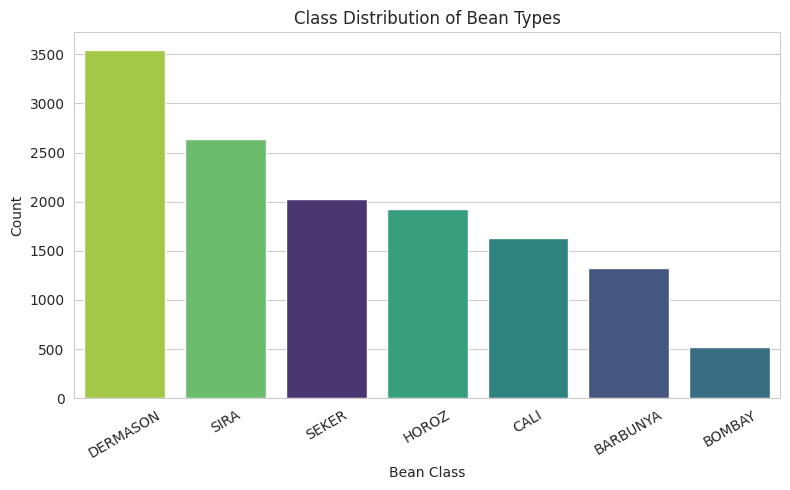

In [4]:
fig = eda.plot_class_distribution(df)
plt.show()

### 2.2 Feature distributions (histograms)

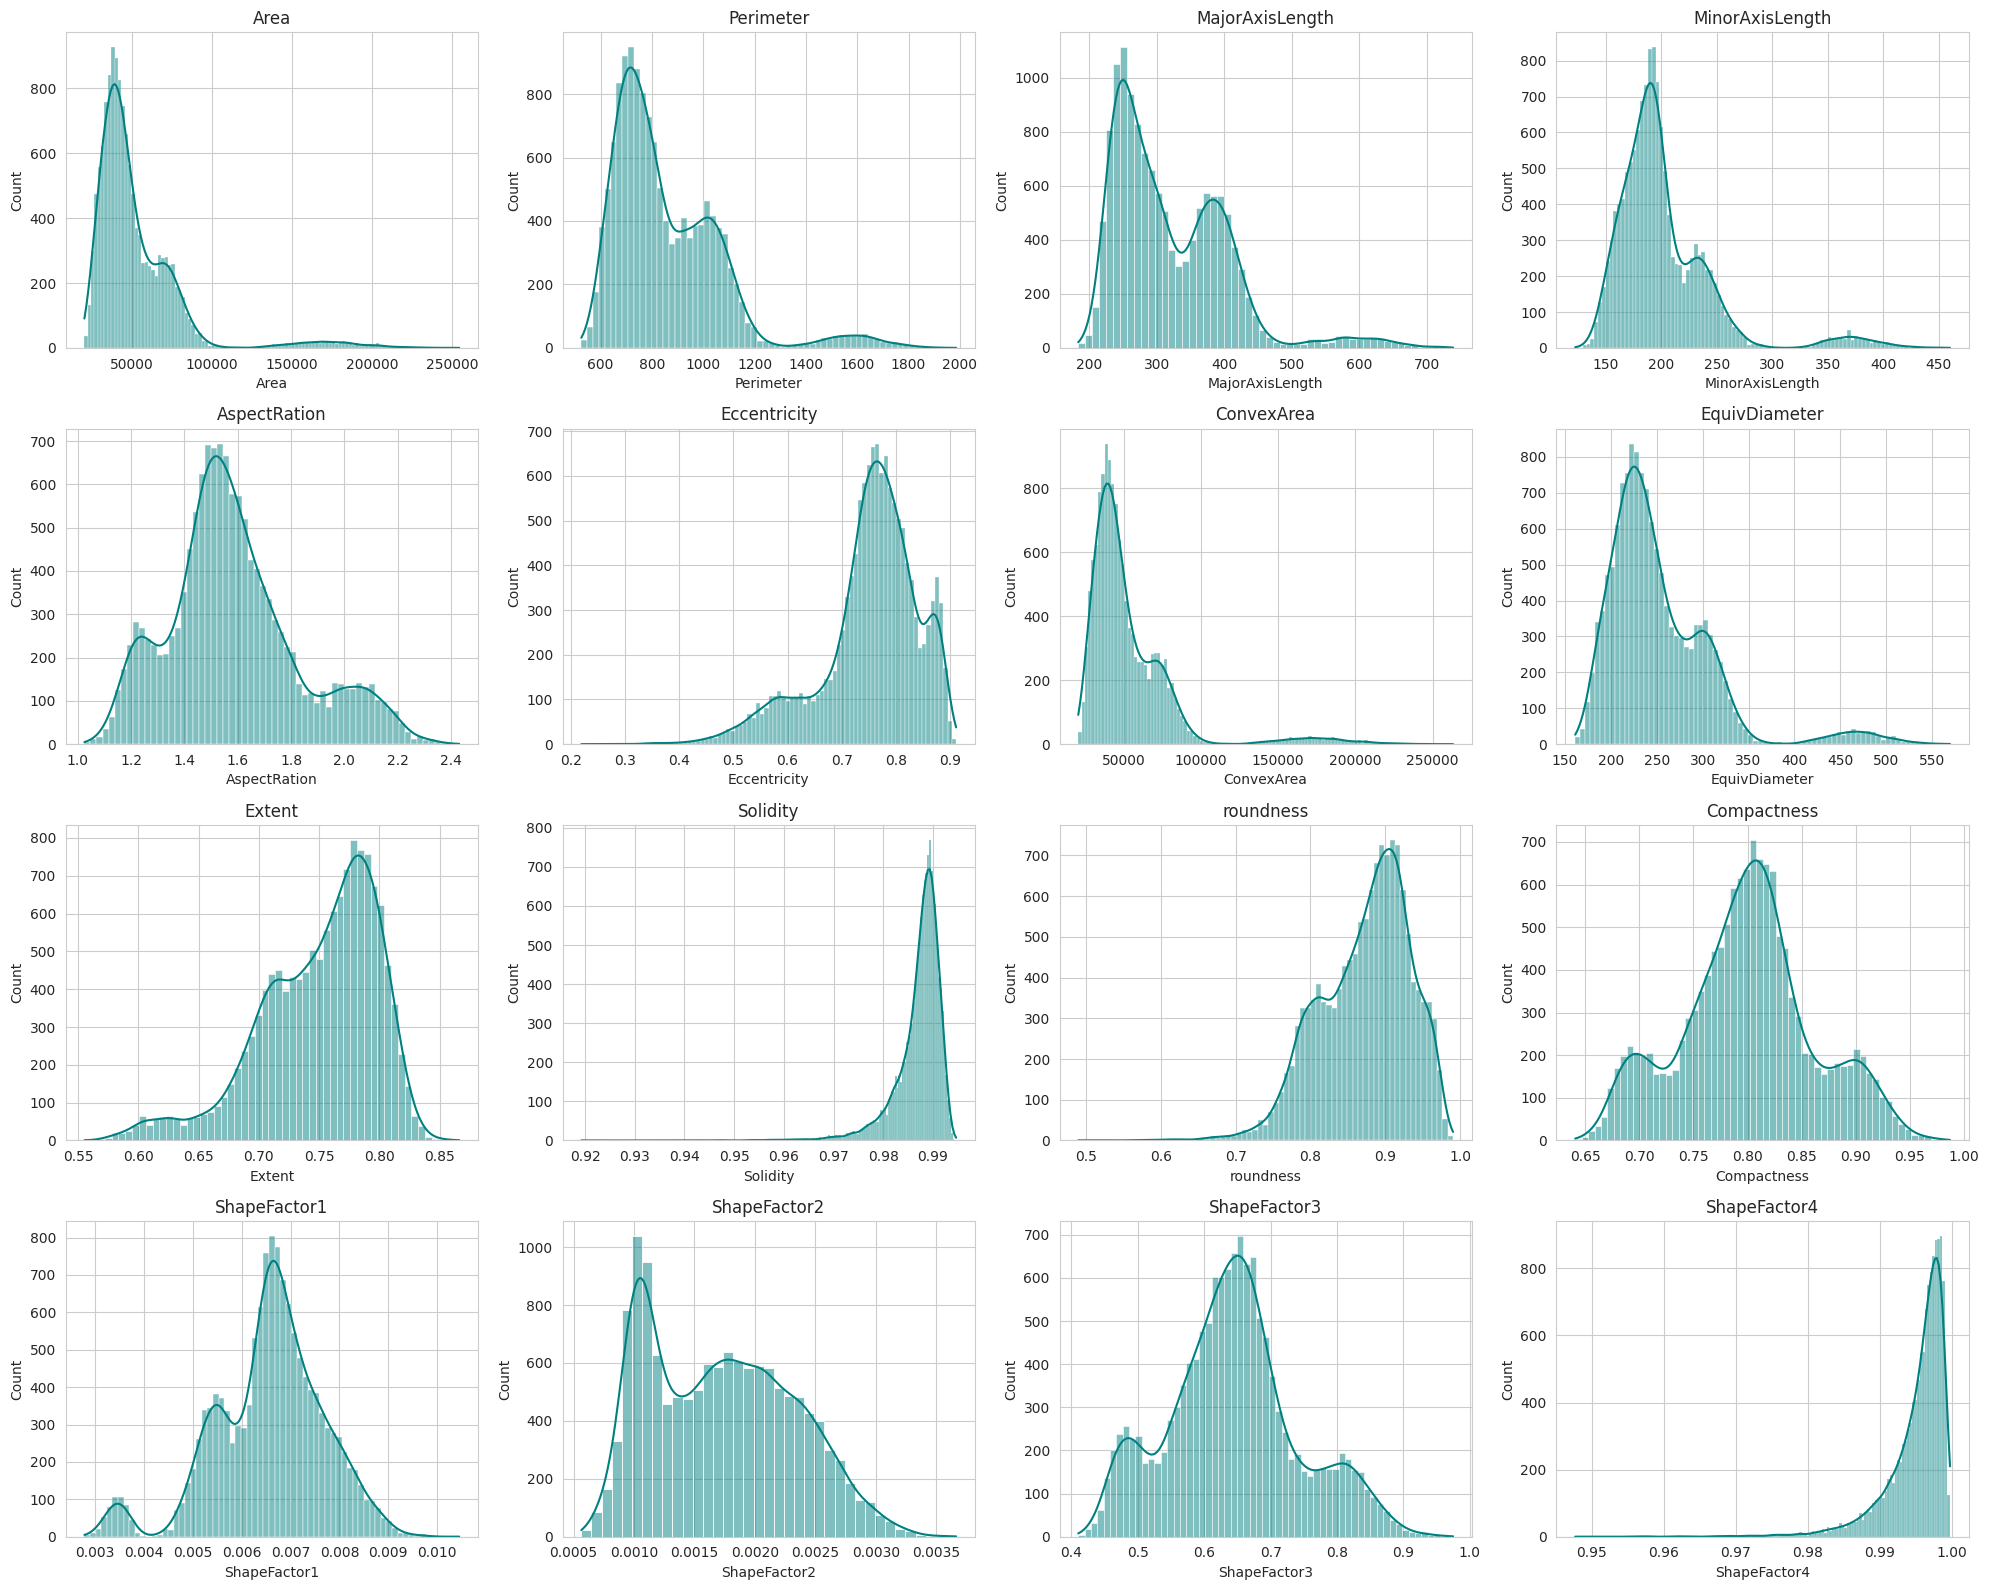

In [5]:
fig = eda.plot_feature_histograms(df)
plt.show()

### 2.3 Outlier check (boxplots)

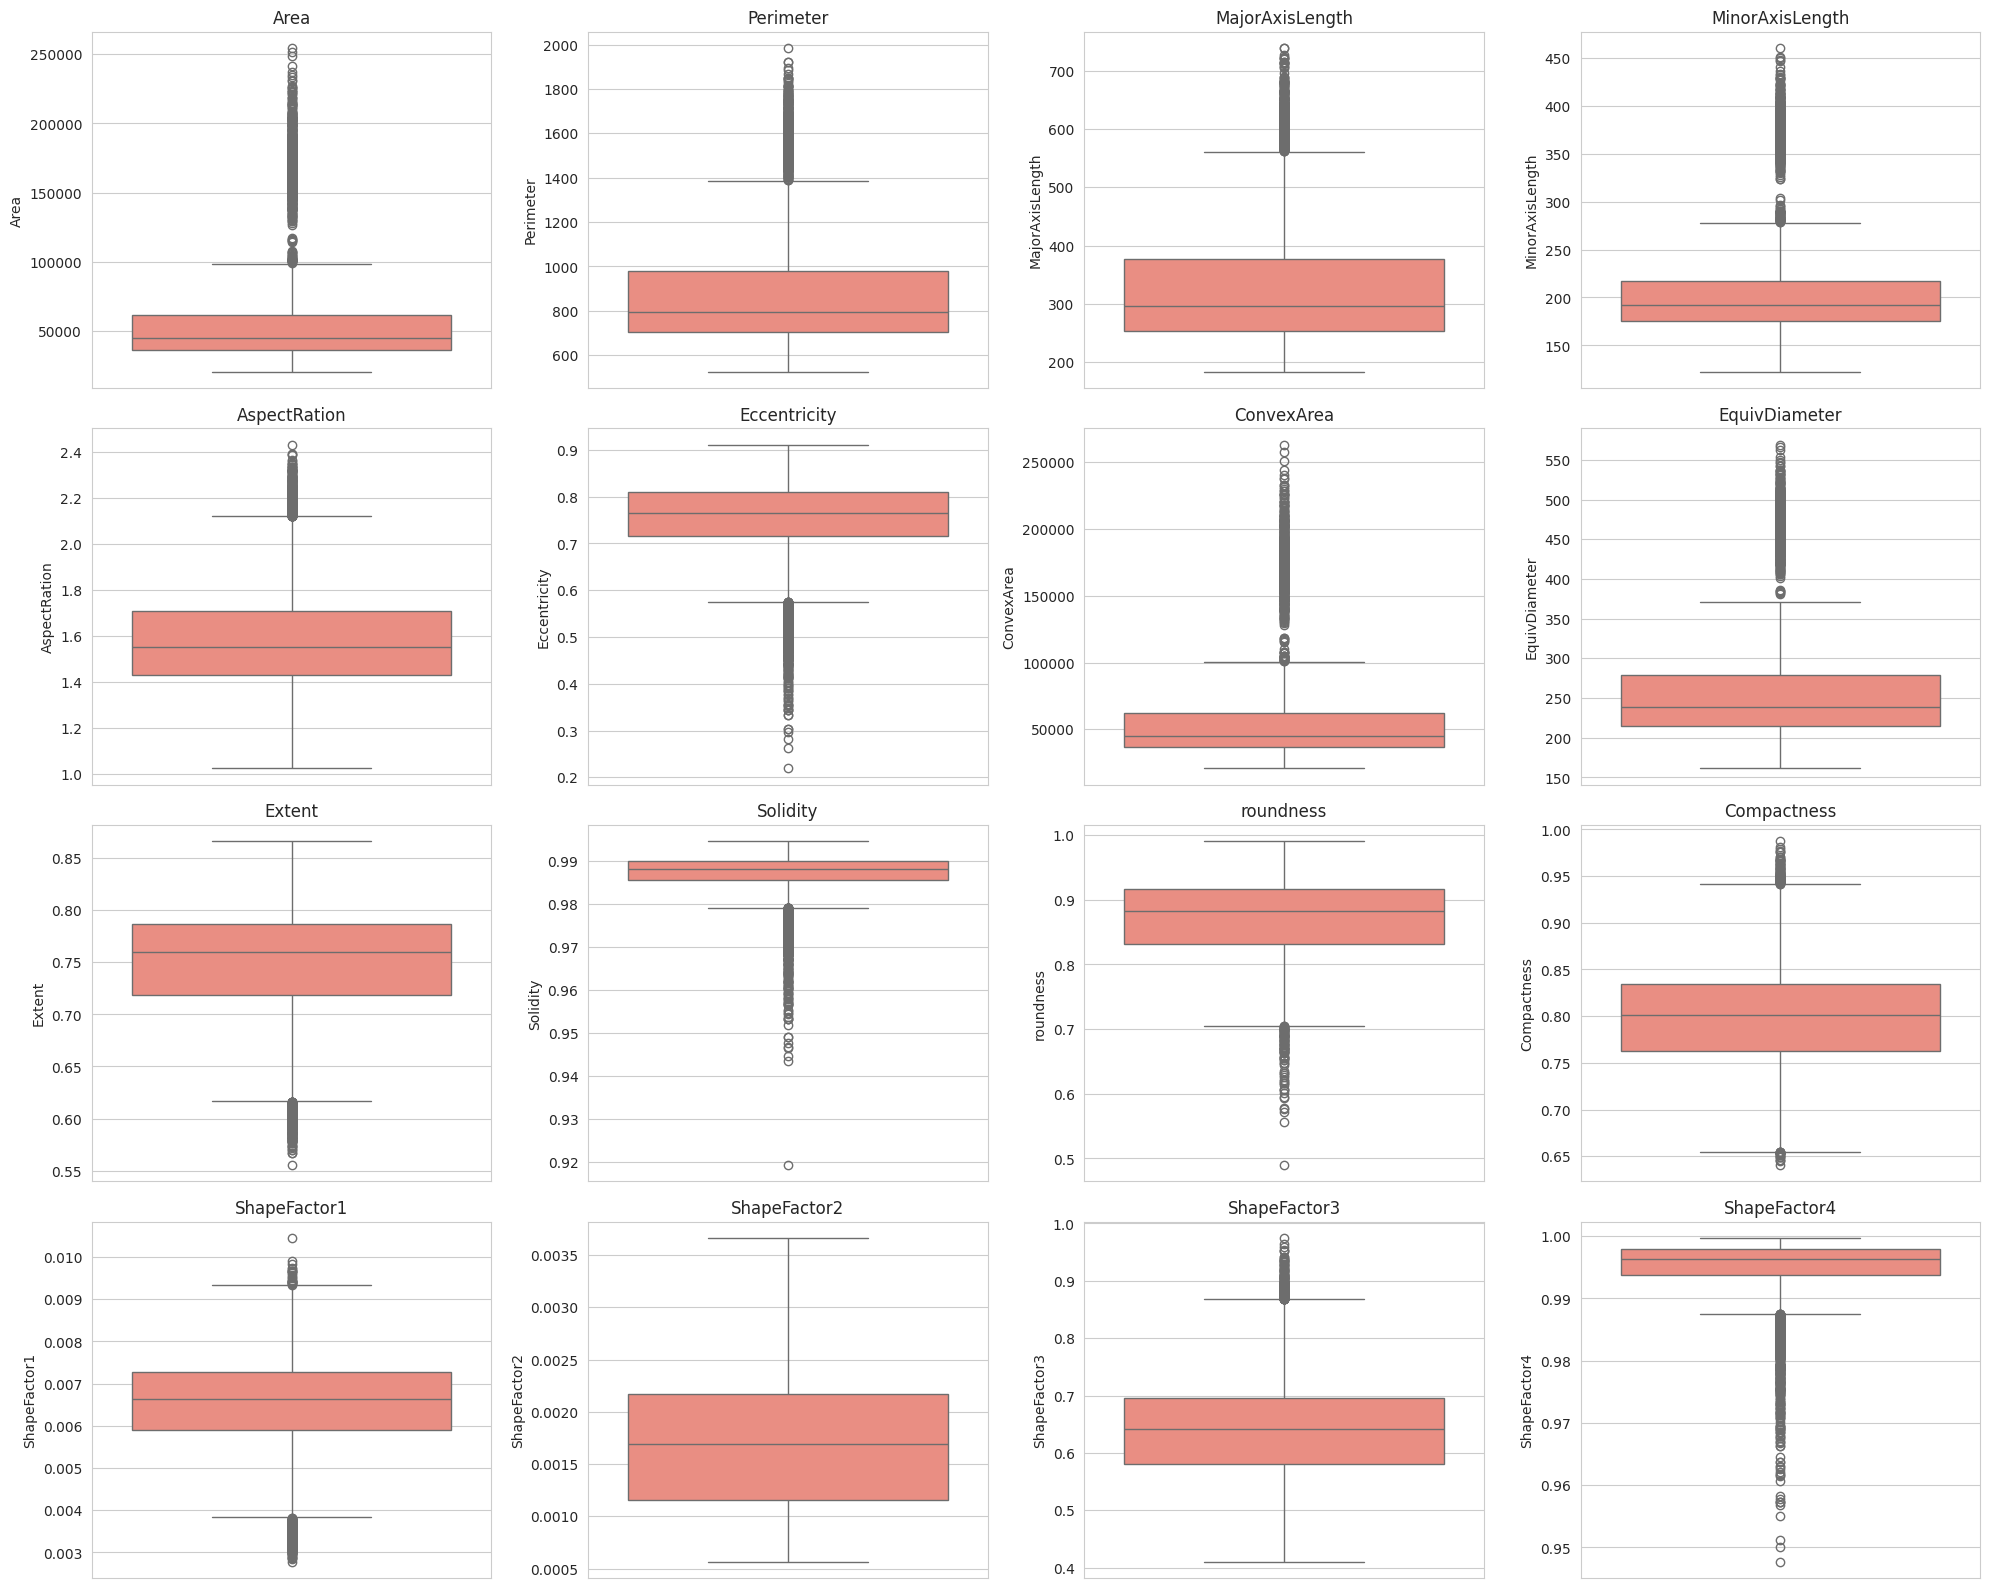

In [6]:
fig = eda.plot_feature_boxplots(df)
plt.show()

### 2.4 Feature correlation heatmap

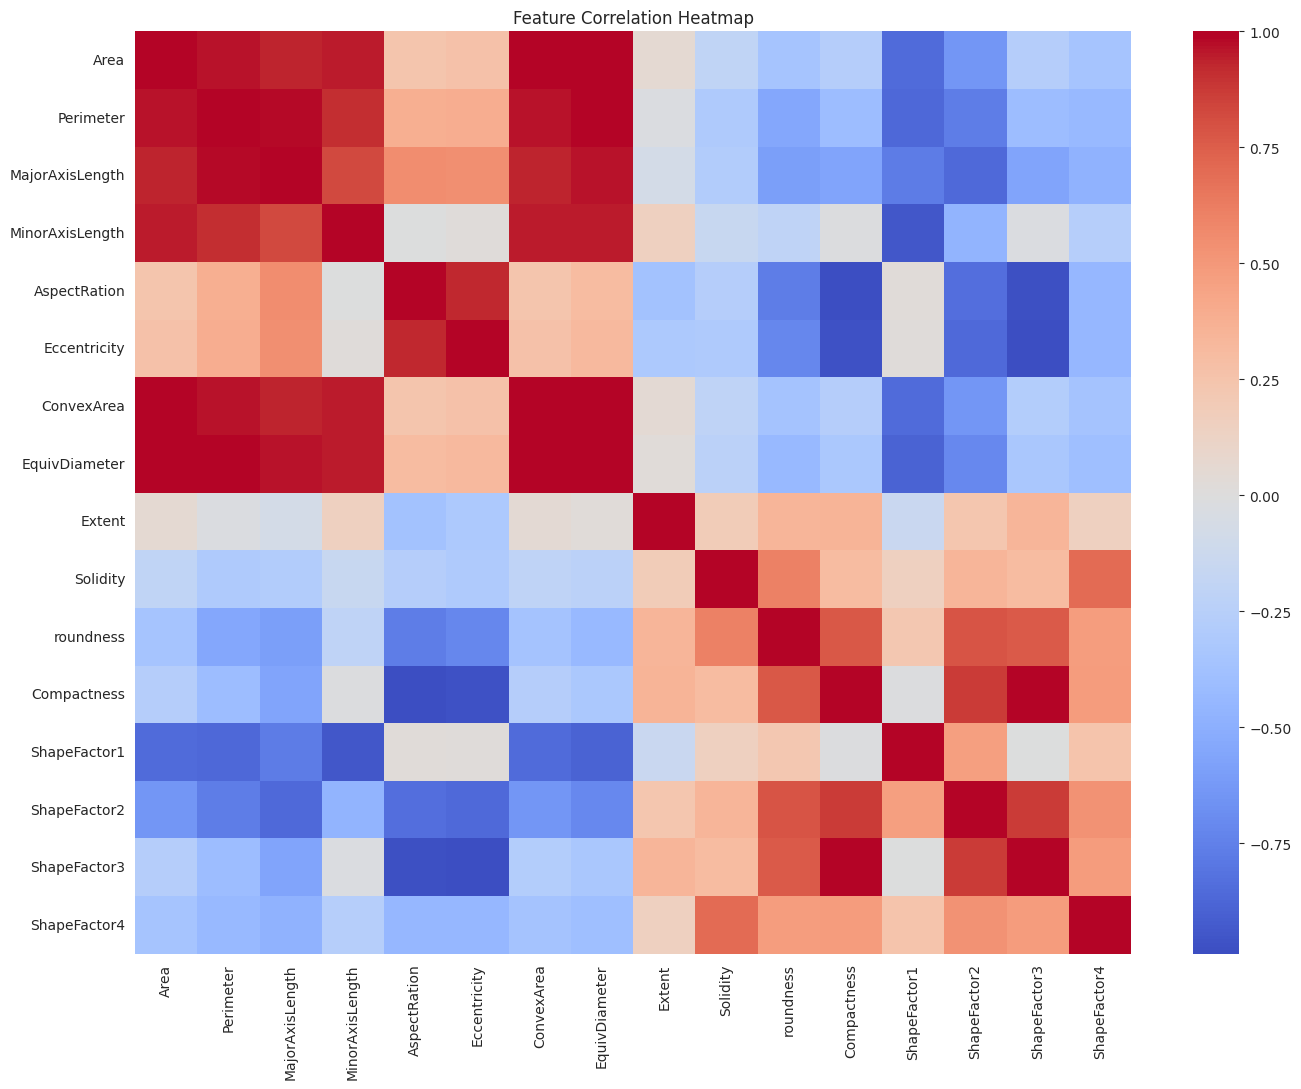

In [7]:
fig = eda.plot_correlation_heatmap(df)
plt.show()

### 2.5 Pairplot of key size/shape features by class

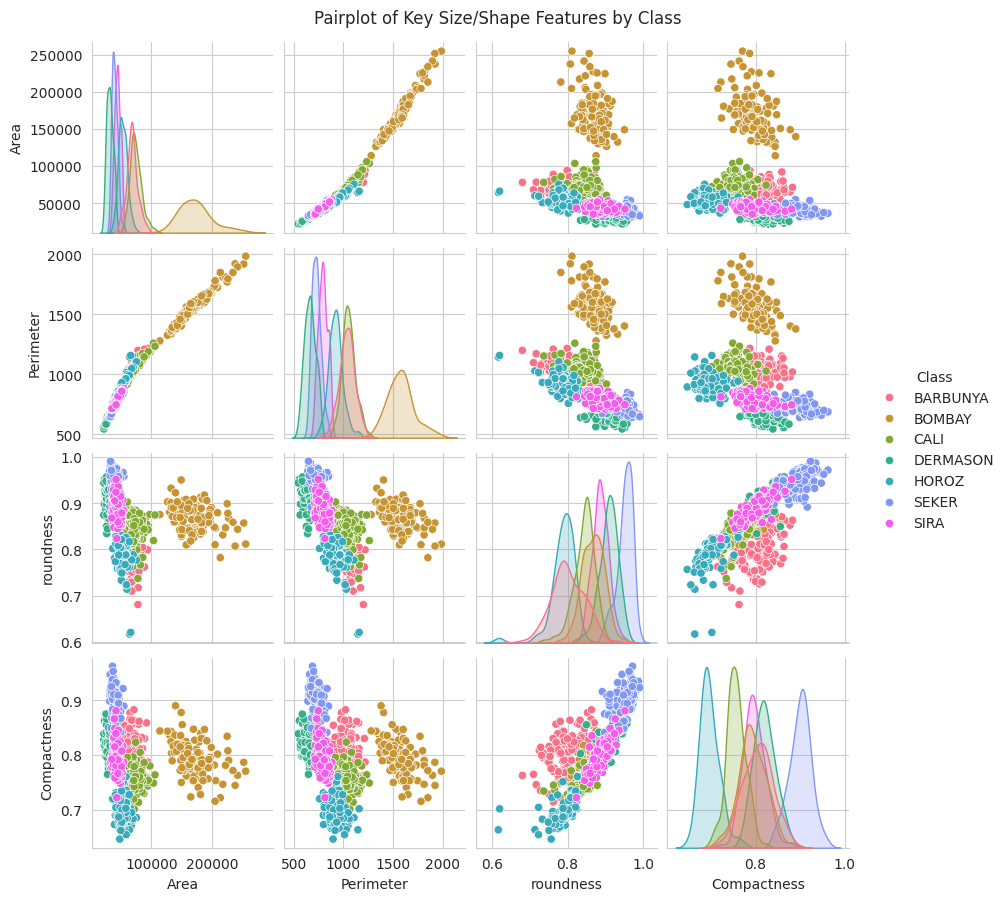

In [8]:
g = eda.plot_pairplot(df)
plt.show()

### 2.6 Key EDA findings (summarised)

In [9]:
eda.summarize_key_findings(df)

KEY EDA FINDINGS
------------------------------------------------------------
1. Dataset has 13611 samples across 7 bean classes.
2. Largest class: DERMASON (3546 samples). Smallest class: BOMBAY (522 samples).
3. Imbalance ratio (largest/smallest) = 6.8x -> meaningful imbalance, treatment recommended.
4. Several size-related features (Area, ConvexArea, Perimeter, EquivDiameter) are highly correlated -- expected, since they all describe bean size from different angles.
5. Shape factors and roundness/compactness show visible separation across classes in the pairplot, suggesting they carry strong discriminative signal for the classifier.


## 3. Missing Values & Outlier Treatment

**Why this step matters:** scikit-learn models cannot fit on missing values, so nulls must be found and handled explicitly rather than assumed away. For outliers, we use the **IQR (interquartile range) method** rather than Z-scores, because several of this dataset's features (Area, Perimeter) are right-skewed rather than normally distributed, and IQR doesn't assume normality.

**Why we cap outliers instead of deleting rows:** this is a multiclass problem with an already-rare class (BOMBAY, ~520 samples out of 13,611). Deleting "outlier" rows risks disproportionately removing legitimate large/small beans of that minority class and making the imbalance worse. Capping (winsorizing) keeps every row and its class label while limiting the influence of extreme values on distance-based models like KNN and SVM.

In [10]:
missing = prep.check_missing_values(df)

No missing values found.


In [11]:
outlier_report = prep.detect_outliers_iqr(df)
outlier_report

,outlier_count,outlier_pct
Eccentricity,843,6.19
Solidity,778,5.72
ShapeFactor4,767,5.64
MinorAxisLength,569,4.18
Area,551,4.05
ConvexArea,550,4.04
ShapeFactor1,533,3.92
EquivDiameter,526,3.86
Perimeter,500,3.67
AspectRation,473,3.48


In [12]:
df_clean = prep.handle_missing_values(df)
df_clean = prep.cap_outliers_iqr(df_clean)
print("Outlier treatment applied. Shape unchanged (no rows dropped):", df_clean.shape)

Outlier treatment applied. Shape unchanged (no rows dropped): (13611, 17)


## 4. Feature Engineering & Preprocessing

**Why each sub-step matters:**
- **Skewness check** — tells us whether any feature is skewed enough to warrant special handling before feeding it to distance-based models.
- **Label encoding the target** — converts string class names (e.g. `'SEKER'`) into integers models can consume. We **persist the fitted encoder to disk** so the Streamlit app can later convert a model's integer prediction back into a human-readable class name using the *exact same* mapping learned here — not a re-derived one that could drift.
- **Stratified train/test split** — with class sizes ranging from ~520 to ~3500, a plain random split risks the test set ending up with too few samples of the rarest class. `stratify=y` keeps the same class proportions in both splits.
- **Feature scaling (StandardScaler)** — fit **only on the training data**, then applied to both train and test. Fitting on the full dataset (including test data) would leak test-set information into training ("data leakage"), producing an overly optimistic — and wrong — accuracy estimate. The fitted scaler is also persisted, so the Streamlit app scales a brand-new bean's measurements identically to how training data was scaled.

In [13]:
skew = prep.check_skewness(df_clean)

Skewness per feature (sorted by magnitude):
ShapeFactor4      -1.040172
MajorAxisLength    0.971004
ConvexArea         0.963532
Perimeter          0.961668
Area               0.956989
Solidity          -0.844704
EquivDiameter      0.832987
Extent            -0.783295
MinorAxisLength    0.727810
Eccentricity      -0.610125
roundness         -0.492208
AspectRation       0.472940
ShapeFactor1      -0.329187
ShapeFactor2       0.301226
ShapeFactor3       0.193072
Compactness        0.018794
dtype: float64

Features above |skew| > 1.0: ['ShapeFactor4']


In [14]:
y_encoded, label_encoder = prep.encode_target(df_clean, fit=True)
print("Classes:", list(label_encoder.classes_))

Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


In [15]:
X_train, X_test, y_train, y_test = prep.split_data(df_clean, y_encoded)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", pd.Series(y_train).value_counts(normalize=True).round(3))
print("Test class balance:\n",  pd.Series(y_test).value_counts(normalize=True).round(3))

Train shape: (10888, 16)  Test shape: (2723, 16)
Train class balance:
 3    0.261
6    0.194
5    0.149
4    0.142
2    0.120
0    0.097
1    0.038
Name: proportion, dtype: float64
Test class balance:
 3    0.260
6    0.194
5    0.149
4    0.142
2    0.120
0    0.097
1    0.038
Name: proportion, dtype: float64


In [16]:
X_train_scaled, X_test_scaled, scaler = prep.scale_features(X_train, X_test)
print("Scaling complete. scaler.joblib, label_encoder.joblib, and feature_names.json saved to models/")

Scaling complete. scaler.joblib, label_encoder.joblib, and feature_names.json saved to models/


## 5. Model Building — Try Multiple Classifiers (with Cross-Validation)

**Why train several algorithm families instead of picking one upfront:** no single algorithm is best for every dataset. We compare a linear model (Logistic Regression), tree-based models (Decision Tree, Random Forest), a distance-based model (KNN), a margin-based model (SVM), a probabilistic model (Naive Bayes), and boosting ensembles (AdaBoost, Gradient Boosting) — giving an evidence-based answer to which approach fits *this* bean-shape data best.

**Why cross-validation on top of the single train/test split:** a single split's accuracy can vary by chance depending on which rows land in the test set. **Stratified 5-fold cross-validation** trains and evaluates each model 5 times on different folds (preserving class proportions in every fold) and averages the result — a far more reliable performance estimate than one lucky/unlucky split.

*Note: SVM is trained here with `probability=False` for speed, since Platt-scaling probability estimates add an expensive internal cross-validation inside every SVM fit. We only pay that cost once for whichever model is ultimately deployed (see Task 8).*

In [17]:
baseline_models = modeling.get_candidate_models(class_weight=None)
fitted_baseline, cv_results = modeling.train_and_cross_validate_all(
    baseline_models, X_train_scaled, y_train, cv_folds=config.CV_FOLDS
)

Training & cross-validating: Logistic Regression ...


  CV accuracy: 0.9247 (+/- 0.0030)
Training & cross-validating: Decision Tree ...


  CV accuracy: 0.8998 (+/- 0.0024)
Training & cross-validating: Random Forest ...


  CV accuracy: 0.9227 (+/- 0.0061)
Training & cross-validating: KNN ...


  CV accuracy: 0.9239 (+/- 0.0044)
Training & cross-validating: SVM ...


  CV accuracy: 0.9317 (+/- 0.0063)
Training & cross-validating: Naive Bayes ...
  CV accuracy: 0.8980 (+/- 0.0030)
Training & cross-validating: AdaBoost ...


  CV accuracy: 0.8481 (+/- 0.0088)
Training & cross-validating: Gradient Boosting (Ensemble) ...


  CV accuracy: 0.9258 (+/- 0.0044)


In [18]:
baseline_eval = []
for name, model in fitted_baseline.items():
    result = ev.evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, label_encoder, name)
    result["cv_mean_accuracy"] = cv_results[name]["cv_mean_accuracy"]
    baseline_eval.append(result)


Model: Logistic Regression
Train Accuracy : 0.9258
Test Accuracy  : 0.9243
Weighted F1    : 0.9245
Overfitting gap: 0.0014 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.85      0.88      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723


Model: Decision Tree
Train Accuracy : 0.9937
Test Accuracy  : 0.8964
Weighted F1    : 0.8964
Overfitting gap: 0.0972 -> LIKELY OVERFITTING

Per-class classification report (test set):
              precision    recall  f1-score


Model: Random Forest
Train Accuracy : 0.9986
Test Accuracy  : 0.9221
Weighted F1    : 0.9221
Overfitting gap: 0.0765 -> LIKELY OVERFITTING

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.93      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723




Model: KNN
Train Accuracy : 0.9359
Test Accuracy  : 0.9159
Weighted F1    : 0.9161
Overfitting gap: 0.0200 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.90      0.91      0.90       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.86      0.85       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723




Model: SVM
Train Accuracy : 0.9342
Test Accuracy  : 0.9247
Weighted F1    : 0.9247
Overfitting gap: 0.0095 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.91      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.95      0.95       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723


Model: Naive Bayes
Train Accuracy : 0.8984
Test Accuracy  : 0.8997
Weighted F1    : 0.8999
Overfitting gap: -0.0013 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.


Model: Gradient Boosting (Ensemble)
Train Accuracy : 0.9740
Test Accuracy  : 0.9207
Weighted F1    : 0.9206
Overfitting gap: 0.0533 -> LIKELY OVERFITTING

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.92      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.95      0.96      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [19]:
baseline_table = ev.build_comparison_table(baseline_eval)
baseline_table

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,SVM,0.9342,0.9247,0.9247,N
1,Logistic Regression,0.9258,0.9243,0.9245,N
2,Random Forest,0.9986,0.9221,0.9221,Y
3,Gradient Boosting (Ensemble),0.9740,0.9207,0.9206,Y
4,KNN,0.9359,0.9159,0.9161,N
5,Naive Bayes,0.8984,0.8997,0.8999,N
6,Decision Tree,0.9937,0.8964,0.8964,Y
7,AdaBoost,0.8381,0.8223,0.8095,N


Confusion matrix for the strongest baseline model so far:

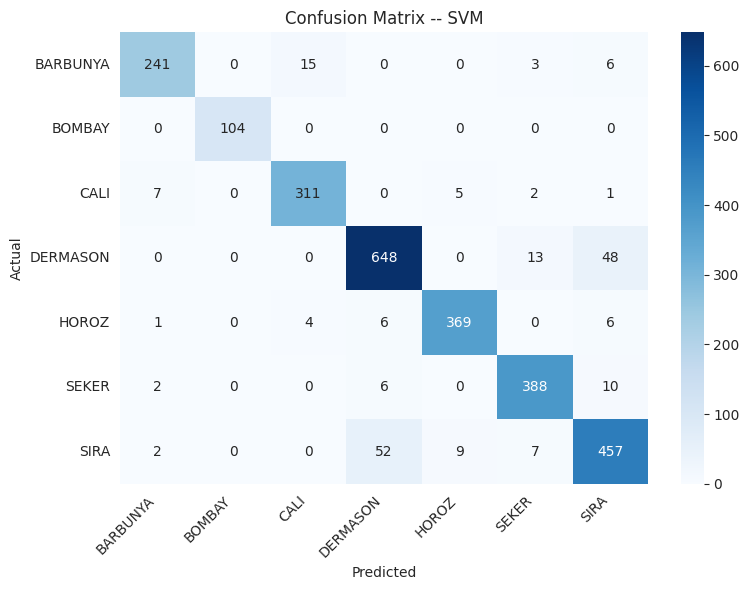

In [20]:
best_baseline_name = baseline_table.iloc[0]["Model"]
fig = ev.plot_confusion_matrix(
    fitted_baseline[best_baseline_name], X_test_scaled, y_test, label_encoder,
    model_name=best_baseline_name
)
plt.show()

## 6. Handling Class Imbalance

**Why this step matters:** EDA showed BOMBAY has ~520 samples vs DERMASON's ~3500 — roughly a 6.8x imbalance. A model can reach high *overall* accuracy while performing poorly on the rare classes, which is unacceptable for a real quality-control use case. We compare three standard techniques:
- **SMOTE** — generates *synthetic* minority-class samples by interpolating between real minority-class neighbours (rather than just duplicating rows), giving the model more varied examples of what a rare bean type's measurements can look like.
- **Random oversampling** — the simplest baseline: duplicate minority rows until classes are balanced.
- **Class weighting** — doesn't touch the data at all; instead it tells the model's loss function to penalise mistakes on rare classes more heavily.

**Why this is applied only to the top-performing models from Task 5, and never to the test set:** resampling must only touch training data, or the reported test metrics would be evaluated partly on synthetic data instead of real, unseen beans — an easy way to fool yourself into overestimating real-world performance. Restricting this to the top 3 baseline models (instead of all 8) keeps runtime reasonable — SMOTE roughly doubles the training set size, and the weakest baseline models rarely turn into the eventual winner after imbalance treatment.

In [21]:
X_train_smote, y_train_smote = imb.apply_smote(X_train_scaled, y_train)

Before SMOTE: Counter({np.int64(3): 2837, np.int64(6): 2109, np.int64(5): 1621, np.int64(4): 1542, np.int64(2): 1304, np.int64(0): 1057, np.int64(1): 418})
After SMOTE:  Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})


In [22]:
class_weights = imb.compute_class_weights(y_train)
print("Balanced class weights:", class_weights)

Balanced class weights: {np.int64(0): np.float64(1.4715502094877686), np.int64(1): np.float64(3.721120984278879), np.int64(2): np.float64(1.1928133216476775), np.int64(3): np.float64(0.5482652701545898), np.int64(4): np.float64(1.0087085417824717), np.int64(5): np.float64(0.9595487794130607), np.int64(6): np.float64(0.7375194743615796)}


In [23]:
top3_names = baseline_table["Model"].head(3).tolist()
print("Re-training top 3 baseline models on SMOTE-resampled data:", top3_names)

imbalance_eval = []
smote_fitted = {}
for name in top3_names:
    m = modeling.get_candidate_models(class_weight=None)[name]
    m.fit(X_train_smote, y_train_smote)
    smote_fitted[name] = m
    result = ev.evaluate_model(
        m, X_train_smote, y_train_smote, X_test_scaled, y_test, label_encoder,
        model_name=f"{name} + SMOTE"
    )
    imbalance_eval.append(result)

Re-training top 3 baseline models on SMOTE-resampled data: ['SVM', 'Logistic Regression', 'Random Forest']



Model: SVM + SMOTE
Train Accuracy : 0.9481
Test Accuracy  : 0.9236
Weighted F1    : 0.9237
Overfitting gap: 0.0245 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.93      0.90      0.91       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.96      0.94       406
        SIRA       0.85      0.89      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.92      0.92      0.92      2723




Model: Logistic Regression + SMOTE
Train Accuracy : 0.9414
Test Accuracy  : 0.9199
Weighted F1    : 0.9202
Overfitting gap: 0.0215 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.92      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.94      0.88      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.96      0.94       406
        SIRA       0.83      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723




Model: Random Forest + SMOTE
Train Accuracy : 0.9985
Test Accuracy  : 0.9210
Weighted F1    : 0.9210
Overfitting gap: 0.0775 -> LIKELY OVERFITTING

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.94      0.97      0.95       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [24]:
imbalance_table = ev.build_comparison_table(imbalance_eval)
imbalance_table

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,SVM + SMOTE,0.9481,0.9236,0.9237,N
1,Random Forest + SMOTE,0.9985,0.9210,0.9210,Y
2,Logistic Regression + SMOTE,0.9414,0.9199,0.9202,N


## 7. Model Evaluation & Overfitting Check

**Why accuracy alone isn't enough:** given the class imbalance, per-class **Precision, Recall, and F1-Score** reveal failures that overall accuracy can hide (e.g. a model that's great at DERMASON but poor at BOMBAY). **Weighted F1** is used as the single headline metric because, with 7 imbalanced classes, it accounts for how many true instances of each class exist — a fairer summary than macro-F1 for this business context.

**Overfitting check:** we compare **train vs test accuracy** directly. A gap greater than ~5 percentage points is flagged as likely overfitting — a common practical heuristic (not a hard statistical rule) meant to prompt closer scrutiny of models like an un-pruned Decision Tree that can memorise training data.

The evaluation calls below already happened inside Tasks 5 and 6 (`evaluate_model` printed full classification reports and computed the overfitting flag for every model) — here we combine both result sets to pick the single best, least-overfit candidate to carry into hyperparameter tuning.

In [25]:
combined_eval = baseline_eval + imbalance_eval
combined_table = ev.build_comparison_table(combined_eval)
combined_table

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,SVM,0.9342,0.9247,0.9247,N
1,Logistic Regression,0.9258,0.9243,0.9245,N
2,SVM + SMOTE,0.9481,0.9236,0.9237,N
3,Random Forest,0.9986,0.9221,0.9221,Y
4,Random Forest + SMOTE,0.9985,0.9210,0.9210,Y
5,Gradient Boosting (Ensemble),0.9740,0.9207,0.9206,Y
6,Logistic Regression + SMOTE,0.9414,0.9199,0.9202,N
7,KNN,0.9359,0.9159,0.9161,N
8,Naive Bayes,0.8984,0.8997,0.8999,N
9,Decision Tree,0.9937,0.8964,0.8964,Y


In [26]:
best_row = combined_table.iloc[0]
best_candidate_name = best_row["Model"]
used_smote = "+ SMOTE" in best_candidate_name
base_model_key = best_candidate_name.replace(" + SMOTE", "")
print(f"Best candidate going into hyperparameter tuning: '{best_candidate_name}'")
print(f"  Test Accuracy = {best_row['Test Accuracy']}, F1 = {best_row['F1 Score']}, Overfitting = {best_row['Overfitting (Y/N)']}")

Best candidate going into hyperparameter tuning: 'SVM'
  Test Accuracy = 0.9247, F1 = 0.9247, Overfitting = N


## 8. Hyperparameter Tuning

**Why tuning happens last, only on the winning model family:** `GridSearchCV`/`RandomizedSearchCV` refit a model many times over every parameter combination x every CV fold — expensive. Running that search across all 8 candidate models would be slow and mostly wasted effort. Instead, we spend the tuning budget only on the single best-performing family identified in Task 7.

**GridSearchCV vs RandomizedSearchCV:** GridSearchCV exhaustively tries every combination, appropriate for a small, discrete grid (Random Forest, Decision Tree). RandomizedSearchCV samples a fixed number of combinations instead, which is a better fit for SVM's larger/continuous `C`/`gamma` space — finding a near-optimal setting in a fraction of the time an exhaustive grid would take.

In [27]:
tune_X = X_train_smote if used_smote else X_train_scaled
tune_y = y_train_smote if used_smote else y_train

tunable = {"Random Forest", "SVM", "Decision Tree"}
if base_model_key in tunable:
    best_model, best_params, best_cv_score = tuning.tune_model(
        base_model_key, tune_X, tune_y, cv_folds=3, n_iter=12
    )
else:
    source = {**fitted_baseline, **{f"{n} + SMOTE": smote_fitted[n] for n in top3_names}}
    best_model = source[best_candidate_name]
    best_params = best_model.get_params()
    print(f"No tuning grid defined for '{base_model_key}'; keeping the best baseline fit as-is.")

best_model.fit(tune_X, tune_y)

Tuning SVM using random search ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best params for SVM: {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
Best CV weighted-F1 for SVM: 0.9329


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
# If the winning model is an SVM, rebuild + refit WITH probability estimates
# enabled -- deliberately skipped earlier for speed (see Task 5), and only
# worth paying for once, on the single model we actually deploy. The
# Streamlit app displays this as the model's prediction confidence.
best_model = modeling.enable_probability_if_svm(
    best_model, class_weight=(class_weights if not used_smote else None)
)
best_model.fit(tune_X, tune_y)

final_result = ev.evaluate_model(
    best_model, tune_X, tune_y, X_test_scaled, y_test, label_encoder,
    model_name=f"FINAL TUNED: {best_candidate_name}"
)


Model: FINAL TUNED: SVM
Train Accuracy : 0.9340
Test Accuracy  : 0.9266
Weighted F1    : 0.9266
Overfitting gap: 0.0074 -> OK

Per-class classification report (test set):
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.93       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.95      0.94       326
    DERMASON       0.93      0.90      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



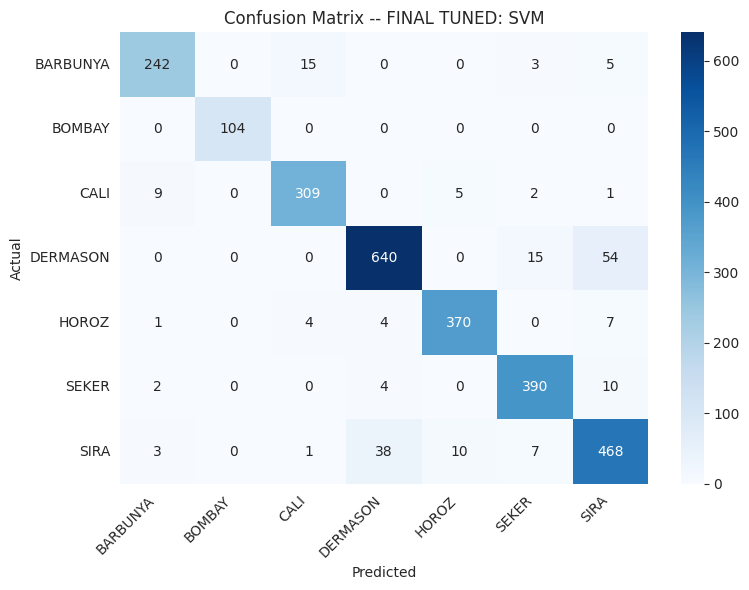

In [29]:
fig = ev.plot_confusion_matrix(
    best_model, X_test_scaled, y_test, label_encoder,
    model_name=f"FINAL TUNED: {best_candidate_name}"
)
plt.show()

## 9. Model Comparison Table

**Why sort by Test Accuracy (not Train Accuracy):** train accuracy rewards memorisation; test accuracy reflects genuine generalisation to beans the model has never seen — what actually matters once this ships as a live Streamlit app processing new camera measurements.

In [30]:
final_eval = baseline_eval + imbalance_eval + [final_result]
final_table = ev.build_comparison_table(final_eval)
final_table

,Model,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,FINAL TUNED: SVM,0.9340,0.9266,0.9266,N
1,SVM,0.9342,0.9247,0.9247,N
2,Logistic Regression,0.9258,0.9243,0.9245,N
3,SVM + SMOTE,0.9481,0.9236,0.9237,N
4,Random Forest,0.9986,0.9221,0.9221,Y
5,Random Forest + SMOTE,0.9985,0.9210,0.9210,Y
6,Gradient Boosting (Ensemble),0.9740,0.9207,0.9206,Y
7,Logistic Regression + SMOTE,0.9414,0.9199,0.9202,N
8,KNN,0.9359,0.9159,0.9161,N
9,Naive Bayes,0.8984,0.8997,0.8999,N


## Saving the Final Model and Deployment Artifacts

We persist everything the Streamlit app needs: the tuned model, the comparison table, and a metadata file recording which model won, its metrics, and its best hyperparameters (useful for the "About This Model" tab in the app, and for anyone auditing this pipeline later).

*(Note: `scaler.joblib`, `label_encoder.joblib`, and `feature_names.json` were already saved back in Task 4.)*

In [31]:
import json, joblib
from datetime import datetime

joblib.dump(best_model, config.BEST_MODEL_PATH)
final_table.to_csv(config.MODEL_COMPARISON_PATH, index=False)

metadata = {
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "best_model_name": best_candidate_name,
    "used_smote": used_smote,
    "test_accuracy": float(final_result["test_accuracy"]),
    "train_accuracy": float(final_result["train_accuracy"]),
    "weighted_f1": float(final_result["weighted_f1"]),
    "overfitting_gap": float(final_result["overfit_gap"]),
    "best_params": {k: (v if isinstance(v, (int, float, str, bool)) or v is None else str(v))
                     for k, v in (best_params or {}).items()},
    "classes": list(label_encoder.classes_),
}
with open(config.METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: best_model.joblib, model_comparison.csv, metadata.json")
print(json.dumps(metadata, indent=2))

Saved: best_model.joblib, model_comparison.csv, metadata.json
{
  "trained_at": "2026-08-23T12:38:05",
  "best_model_name": "SVM",
  "used_smote": false,
  "test_accuracy": 0.9265515975027543,
  "train_accuracy": 0.9339639970609845,
  "weighted_f1": 0.9266450851999772,
  "overfitting_gap": 0.007412399558230254,
  "best_params": {
    "kernel": "rbf",
    "gamma": 0.1,
    "C": 1
  },
  "classes": [
    "BARBUNYA",
    "BOMBAY",
    "CALI",
    "DERMASON",
    "HOROZ",
    "SEKER",
    "SIRA"
  ]
}


## 10. Build a Simple Classifier App (Streamlit)

**Why the app is a separate file (`app.py`), not more notebook cells:** a Streamlit app runs as its own live server process (`streamlit run app.py`), which isn't something a notebook cell can start and keep running interactively. The app is deliberately kept thin — it just loads the artifacts saved above (`best_model.joblib`, `scaler.joblib`, `label_encoder.joblib`, `feature_names.json`) and applies the *exact same* scaling used here to any new bean measurement, guaranteeing the app can never drift out of sync with what was actually trained and evaluated in this notebook.

**To launch the app** (from the project root, after this notebook — or `train_pipeline.py` — has been run at least once):

```bash
streamlit run app.py
```

The app provides:
- A **Manual Prediction** tab — enter one bean's measurements via sliders and get an instant predicted class with a confidence chart.
- A **Batch Prediction** tab — upload a CSV of many beans' measurements and download predictions for all of them at once.
- An **About This Model** tab — shows the winning model, its accuracy/F1, best hyperparameters, and class-imbalance strategy, sourced directly from `metadata.json` above.
